# 09 — Subgroup and Fairness Analysis

The notebook performs subgroup and fairness analysis using the final migraine dataset with calibrated probabilities, the optimal decision threshold, and the statistical functions defined in subgroup_fairness.R. It evaluates how the model behaves across treatment conditions, medication groups, clinical subtypes, and environmental air‑quality levels.

In [1]:
library(knitr)

In [2]:
# Load R functions
rm(list = ls())
source("../src/subgroup_fairness.R")
source("../src/visualization.R")

In [3]:
# Load data
data_list <- load_data()
df <- data_list$df
threshold <- data_list$threshold

saveRDS(df, "../data/processed/final_migraine_with_prob.rds")

In [4]:
# Treatment Analysis
treatment_results <- treatment_effect(df, threshold)

cat("\nCoefficient table:\n")
kable(treatment_results$coef_table, digits = 3)

cat("\nOdds Ratio table:\n")
kable(treatment_results$or_table, digits = 3)

write.csv(treatment_results$coef_table, "../reports/tables/treatment_coef_table.csv", row.names = FALSE)
write.csv(treatment_results$or_table, "../reports/tables/treatment_or_table.csv", row.names = FALSE)


Coefficient table:




|term                           | estimate|    se|      z|     p|
|:------------------------------|--------:|-----:|------:|-----:|
|(Intercept)                    |    0.628| 0.468|  1.341| 0.180|
|treatment_phaseUnder treatment |   -0.460| 0.448| -1.027| 0.304|
|sexmale                        |   -0.365| 0.371| -0.984| 0.325|
|age_band31-40                  |   -0.806| 0.574| -1.404| 0.160|
|age_band41-50                  |   -0.571| 0.502| -1.137| 0.256|
|age_band51-66                  |    0.404| 0.455|  0.888| 0.374|
|medicationnone                 |   -0.654| 0.379| -1.725| 0.085|
|medicationreduced              |    0.736| 0.323|  2.280| 0.023|
|prev_attacks                   |    0.032| 0.016|  2.030| 0.042|


Odds Ratio table:




|term                           |    OR| CI_low| CI_high| p_value|
|:------------------------------|-----:|------:|-------:|-------:|
|treatment_phaseUnder treatment | 0.632|  0.263|   1.518|   0.304|
|sexmale                        | 0.694|  0.336|   1.436|   0.325|
|age_band31-40                  | 0.447|  0.145|   1.377|   0.160|
|age_band41-50                  | 0.565|  0.211|   1.511|   0.256|
|age_band51-66                  | 1.498|  0.614|   3.654|   0.374|
|medicationnone                 | 0.520|  0.248|   1.093|   0.085|
|medicationreduced              | 2.087|  1.109|   3.927|   0.023|
|prev_attacks                   | 1.033|  1.001|   1.066|   0.042|

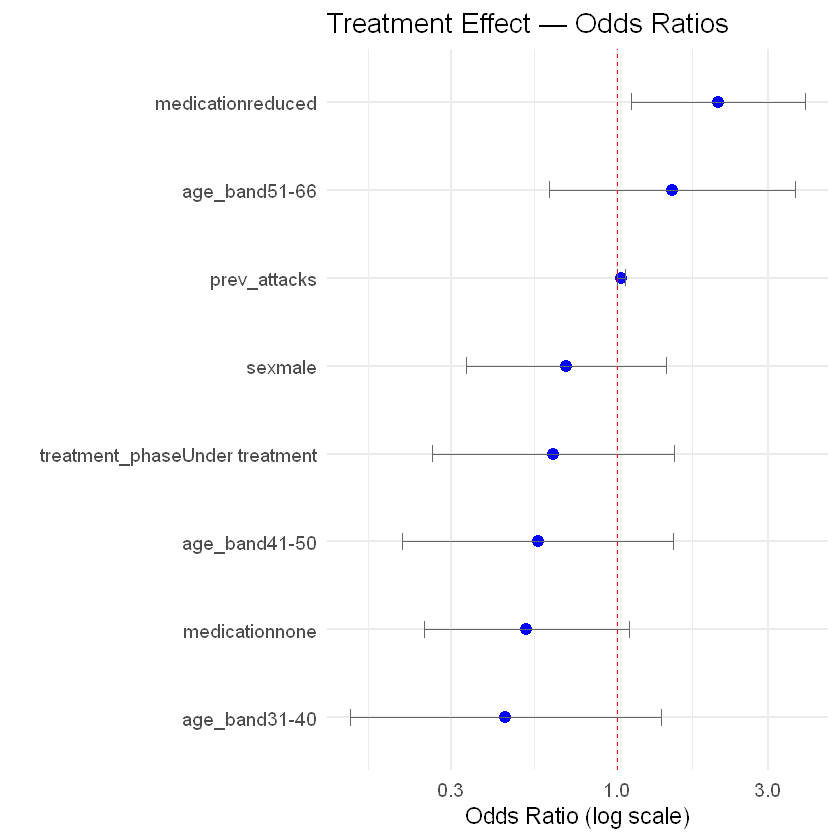

In [5]:
# Visualization
plot_forest(
  or_table = treatment_results$or_table,
  term_filter = NULL,
  label_map = NULL,
  title = "Treatment Effect — Odds Ratios",
  output_path = "../reports/figures/treatment_forest_plot_OR.png"
)

In [6]:
# Medication Comparison
medication_results <- medication_comparison(df)

cat("Medication comparison results:\n\n")
kable(medication_results$summary_attacks, digits = 3)
cat("\n\n")

kable(head(medication_results$df_id, 10), digits = 3)
cat("\n\n")

kable(as.data.frame(medication_results$anova[[1]]), digits = 3)

write.csv(medication_results$summary_attacks, "../reports/tables/medication_summary_attacks.csv", row.names = FALSE)
write.csv(medication_results$df_id, "../reports/tables/medication_df_id.csv", row.names = FALSE)

anova_df <- as.data.frame(medication_results$anova[[1]])
write.csv(anova_df, "../reports/tables/medication_anova.csv", row.names = TRUE)

Medication comparison results:





|medication | mean_attacks| sd_attacks|  n|
|:----------|------------:|----------:|--:|
|none       |        0.440|      0.287| 25|
|reduced    |        0.782|      0.177| 26|
|continuing |        0.661|      0.253| 82|



| id|medication | mean_target|
|--:|:----------|-----------:|
|  1|continuing |       0.950|
|  2|continuing |       0.956|
|  3|continuing |       0.129|
|  4|continuing |       0.879|
|  5|reduced    |       0.883|
|  6|continuing |       0.594|
|  7|continuing |       0.464|
|  8|continuing |       1.000|
|  9|continuing |       0.731|
| 10|continuing |       0.850|



|           |  Df| Sum Sq| Mean Sq| F value| Pr(>F)|
|:----------|---:|------:|-------:|-------:|------:|
|medication |   2|  1.562|   0.781|  12.787|      0|
|Residuals  | 130|  7.939|   0.061|      NA|     NA|

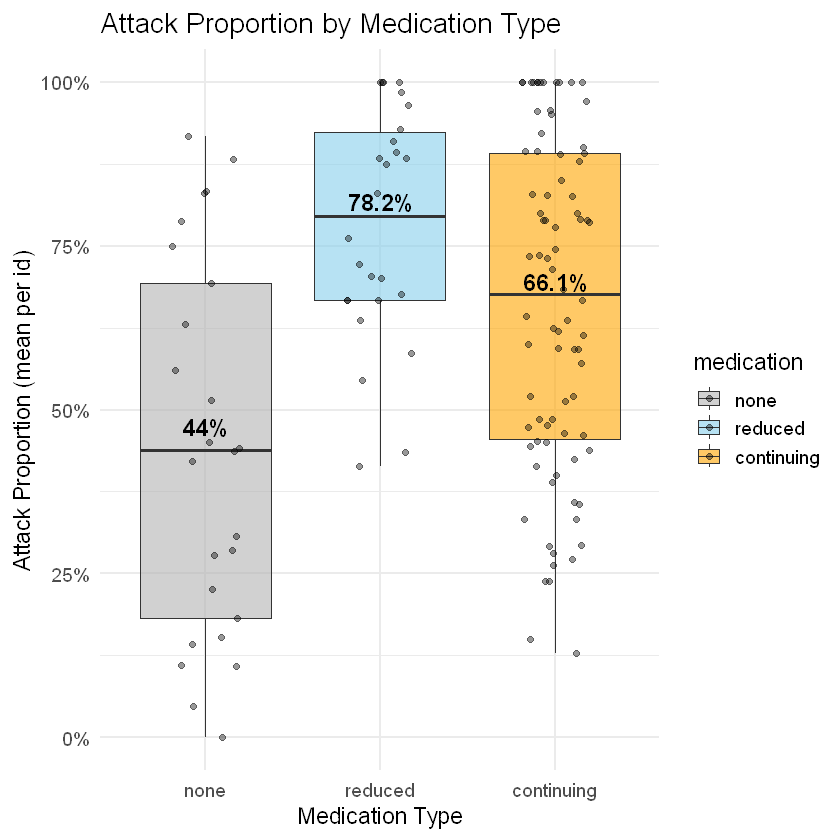

In [7]:
# Visualization
plot_medication_attacks(
  df_id = medication_results$df_id,
  summary_tbl = medication_results$summary_attacks,
  output_path = "../reports/figures/attacks_by_medication.png"
)

In [8]:
# Clinical Subtype Analysis
clinical_results <- clinical_subtype_effect(df, threshold)

cat("Clinical subtype effect results:\n\n")
kable(clinical_results$or_table, digits = 3)
cat("\n\n")

kable(head(clinical_results$df, 10), digits = 3)
cat("\n\n")

write.csv(clinical_results$or_table, "../reports/tables/clinical_subtype_results.csv", row.names = FALSE)

Clinical subtype effect results:





|term          |    OR| CI_low| CI_high| p_value|
|:-------------|-----:|------:|-------:|-------:|
|hatypeAura    | 3.107|  1.607|   6.008|   0.001|
|hatypeMixed   | 1.638|  0.742|   3.616|   0.222|
|sexmale       | 1.087|  0.507|   2.329|   0.831|
|age_band31-40 | 0.505|  0.173|   1.472|   0.211|
|age_band41-50 | 0.442|  0.190|   1.026|   0.057|
|age_band51-66 | 1.233|  0.575|   2.644|   0.590|
|prev_attacks  | 1.015|  0.993|   1.038|   0.182|



| rownames|id | time| dos|hatype | age| airq|medication |headache |sex    |rownames_is_outlier |id_is_outlier |time_is_outlier |dos_is_outlier |age_is_outlier |airq_is_outlier |phase           |study_date | study_month|study_season | days_since_first_visit|age_band | visit_number| target_num| airq_prev_mean| prev_attacks| y_prob| pred|
|--------:|:--|----:|---:|:------|---:|----:|:----------|:--------|:------|:-------------------|:-------------|:---------------|:--------------|:--------------|:---------------|:---------------|:----------|-----------:|:------------|----------------------:|:--------|------------:|----------:|--------------:|------------:|------:|----:|
|        1|1  |  -11| 753|Aura   |  30|    9|continuing |yes      |female |FALSE               |FALSE         |FALSE           |FALSE          |FALSE          |FALSE           |No treatment    |1999-01-24 |           1|winter       |                      0|18-30    |            1|          1|             NA|            0

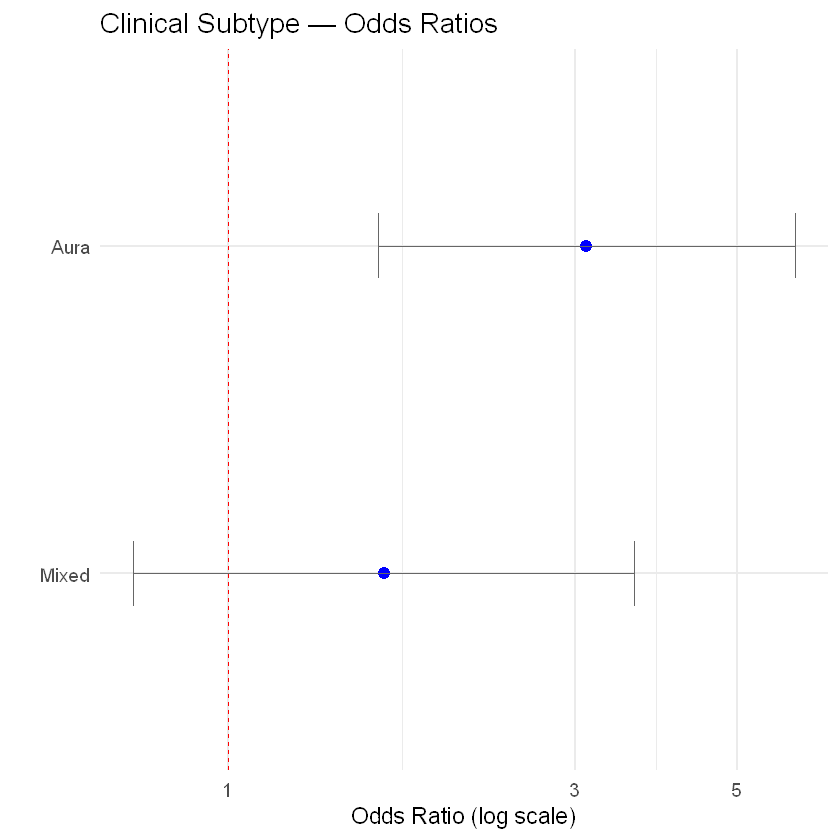

In [9]:
# Visualization
plot_forest(
  or_table = clinical_results$or_table,
  term_filter = c("hatypeAura", "hatypeMixed"),
  label_map = c(hatypeAura = "Aura", hatypeMixed = "Mixed"),
  title = "Clinical Subtype — Odds Ratios",
  output_path = "../reports/figures/clinical_subtype_forest_plot.png"
)

In [10]:
# Clinical Subtype Models Comparison
clinical_models <- clinical_subtype_models_comparison(clinical_results$df)

cat("Model 1 (hatype only):\n\n")
kable(clinical_models$model1, digits = 3)
cat("\n\n")

cat("Model 2 (hatype + covariates):\n\n")
kable(clinical_models$model2, digits = 3)
cat("\n\n")

cat("Comparison (Aura and Mixed):\n\n")
kable(clinical_models$comparison, digits = 3)
cat("\n\n")

# Single combined table for saving
combined_results <- dplyr::bind_rows(
  dplyr::mutate(clinical_models$model1, section = "model1"),
  dplyr::mutate(clinical_models$model2, section = "model2"),
  dplyr::mutate(clinical_models$comparison, section = "comparison")
)

write.csv(combined_results, "../reports/tables/clinical_subtype_models_comparison.csv", row.names = FALSE)

Model 1 (hatype only):





|Model       |term        |    OR| CI_low| CI_high| p_value|
|:-----------|:-----------|-----:|------:|-------:|-------:|
|hatype only |hatypeAura  | 3.253|  1.349|   7.844|   0.009|
|hatype only |hatypeMixed | 2.374|  1.438|   3.920|   0.001|



Model 2 (hatype + covariates):





|Model               |term          |    OR| CI_low| CI_high| p_value|
|:-------------------|:-------------|-----:|------:|-------:|-------:|
|hatype + covariates |hatypeAura    | 3.107|  1.607|   6.008|   0.001|
|hatype + covariates |hatypeMixed   | 1.638|  0.742|   3.616|   0.222|
|hatype + covariates |sexmale       | 1.087|  0.507|   2.329|   0.831|
|hatype + covariates |age_band31-40 | 0.505|  0.173|   1.472|   0.211|
|hatype + covariates |age_band41-50 | 0.442|  0.190|   1.026|   0.057|
|hatype + covariates |age_band51-66 | 1.233|  0.575|   2.644|   0.590|
|hatype + covariates |prev_attacks  | 1.015|  0.993|   1.038|   0.182|



Comparison (Aura and Mixed):





|Model               |term        |    OR| CI_low| CI_high| p_value|
|:-------------------|:-----------|-----:|------:|-------:|-------:|
|hatype only         |hatypeAura  | 3.253|  1.349|   7.844|   0.009|
|hatype only         |hatypeMixed | 2.374|  1.438|   3.920|   0.001|
|hatype + covariates |hatypeAura  | 3.107|  1.607|   6.008|   0.001|
|hatype + covariates |hatypeMixed | 1.638|  0.742|   3.616|   0.222|

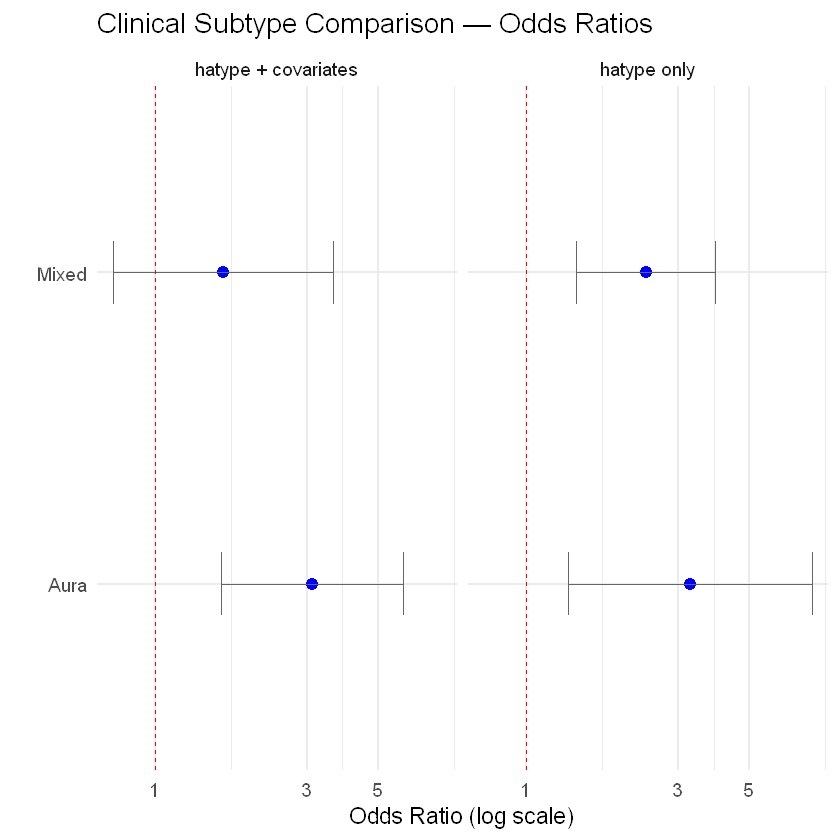

In [11]:
# Visualization
# Plot (uses comparison only)
plot_clinical_subtype_comparison(
  comparison_table = clinical_models$comparison,
  output_path = "../reports/figures/clinical_subtype_model_comparison.png"
)

In [12]:
# Environment Effect Analysis
environment_results <- environment_effect(df, threshold)

cat("Environment effect results:\n\n")
kable(environment_results$or_table, digits = 3)

write.csv(environment_results$or_table, "../reports/tables/environment_effect_results.csv", row.names = FALSE)

Environment effect results:





|term                 |    OR| CI_low| CI_high| p_value|
|:--------------------|-----:|------:|-------:|-------:|
|airq_quartileQ2      | 0.969|  0.756|   1.243|   0.806|
|airq_quartileQ3      | 1.002|  0.736|   1.366|   0.989|
|airq_quartileQ4_high | 1.046|  0.775|   1.413|   0.767|
|sexmale              | 0.969|  0.655|   1.433|   0.873|
|age_band31-40        | 0.879|  0.418|   1.847|   0.734|
|age_band41-50        | 0.597|  0.290|   1.230|   0.162|
|age_band51-66        | 0.734|  0.345|   1.560|   0.421|
|prev_attacks         | 1.021|  0.999|   1.043|   0.059|

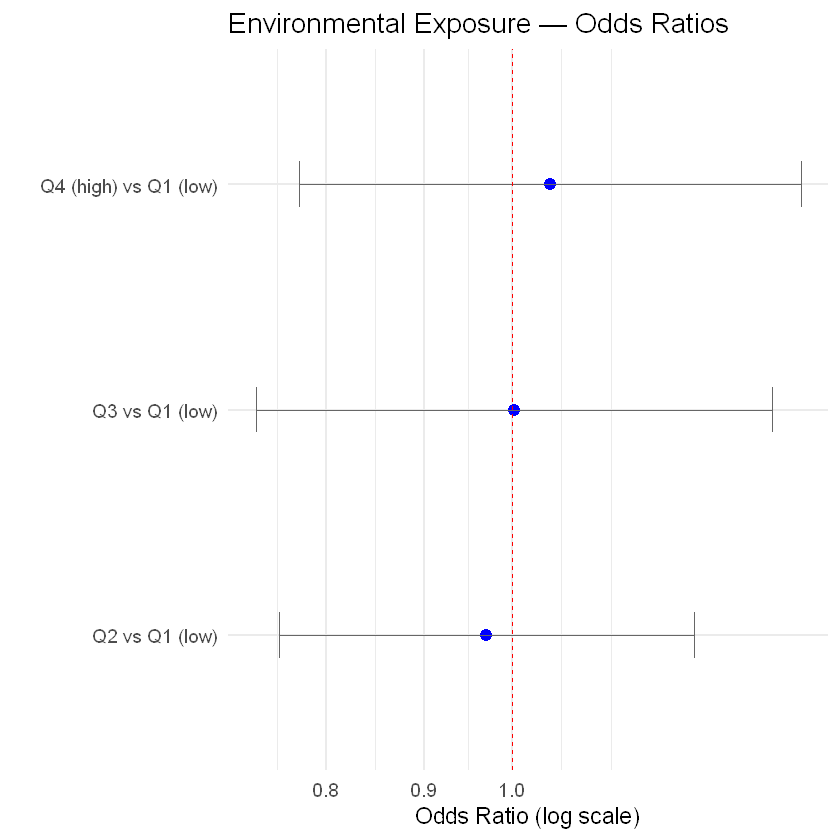

In [13]:
# Visualization
out_airq <- environment_results$or_table

plot_forest(
  or_table = out_airq,
  term_filter = ~ "airq_quartile",
  label_map = c(
    "airq_quartileQ2" = "Q2 vs Q1 (low)",
    "airq_quartileQ3" = "Q3 vs Q1 (low)",
    "airq_quartileQ4_high" = "Q4 (high) vs Q1 (low)"
  ),
  title = "Environmental Exposure — Odds Ratios",
  output_path = "../reports/figures/environment_forest_plot.png"
)

In [14]:
# Fairness
fairness_data <- load_data()
df_fairness <- fairness_data$df
threshold_fairness <- fairness_data$threshold

fair <- compute_fairness_all(df_fairness, threshold_fairness)

fairness_results <- fair$fairness_results
fairness_valid   <- fair$fairness_valid

print(fairness_results)
print(fairness_valid)

write.csv(fairness_results, "../reports/tables/fairness_metrics_results.csv", row.names = FALSE)
write.csv(fairness_valid,   "../reports/tables/fairness_metrics_valid.csv", row.names = FALSE)

# A tibble: 9 × 11
  varia…¹ level    AUC Sensi…² Speci…³     n n_pos n_neg valid…⁴ valid…⁵ valid…⁶
  <chr>   <chr>  <dbl>   <dbl>   <dbl> <int> <int> <int> <lgl>   <lgl>   <lgl>  
1 sex     fema…  0.857      NA       1   113   112     1 TRUE    TRUE    TRUE   
2 sex     male  NA          NA      NA    20    20     0 FALSE   TRUE    FALSE  
3 hatype  Aura  NA          NA      NA    56    56     0 FALSE   TRUE    FALSE  
4 hatype  Mixed NA          NA      NA    12    12     0 FALSE   TRUE    FALSE  
5 hatype  No A…  0.833      NA       1    65    64     1 TRUE    TRUE    TRUE   
6 study_… autu… NA          NA      NA    38    38     0 FALSE   TRUE    FALSE  
7 study_… spri… NA          NA      NA    51    51     0 FALSE   TRUE    FALSE  
8 study_… summ…  1          NA       1    57    56     1 TRUE    TRUE    TRUE   
9 study_… wint… NA          NA      NA    35    34     1 TRUE    TRUE    TRUE   
# … with abbreviated variable names ¹​variable, ²​Sensitivity, ³​Specificity,
#   ⁴​valid_

In [15]:
# Final results fairness
fairness_or_table <- create_fairness_or_table(fairness_valid)

print(fairness_valid)

write.csv(fairness_or_table, "../reports/tables/fairness_or_table.csv", row.names = FALSE)

# A tibble: 4 × 11
  varia…¹ level    AUC Sensi…² Speci…³     n n_pos n_neg valid…⁴ valid…⁵ valid…⁶
  <chr>   <chr>  <dbl>   <dbl>   <dbl> <int> <int> <int> <lgl>   <lgl>   <lgl>  
1 sex     fema…  0.857      NA       1   113   112     1 TRUE    TRUE    TRUE   
2 hatype  No A…  0.833      NA       1    65    64     1 TRUE    TRUE    TRUE   
3 study_… summ…  1          NA       1    57    56     1 TRUE    TRUE    TRUE   
4 study_… wint… NA          NA      NA    35    34     1 TRUE    TRUE    TRUE   
# … with abbreviated variable names ¹​variable, ²​Sensitivity, ³​Specificity,
#   ⁴​valid_auc, ⁵​valid_sens, ⁶​valid_spec


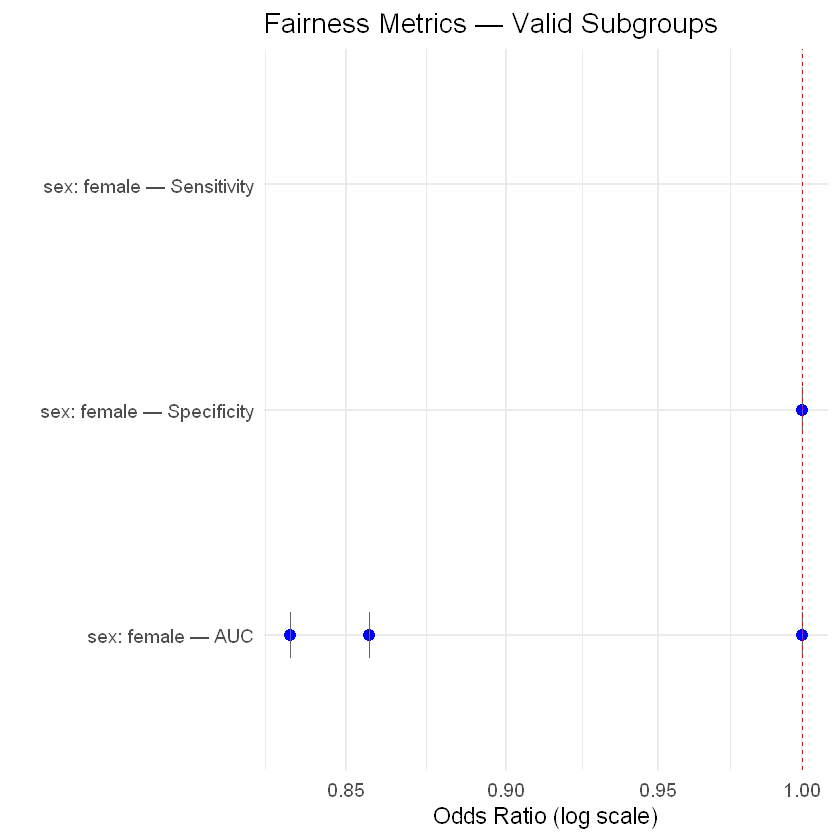

In [16]:
plot_forest(
  or_table    = fairness_or_table,
  term_filter = NULL,
  label_map   = setNames(fairness_or_table$label, fairness_or_table$term),
  title       = "Fairness Metrics — Valid Subgroups",
  output_path = "../reports/figures/fairness_forest_plot.png"
)